In [25]:
import cv2, os, asyncio, json, numpy as np, base64
from pathlib import Path
import nest_asyncio
from IPython.display import display, clear_output
from PIL import Image
from websockets.exceptions import ConnectionClosed

nest_asyncio.apply()

try:
    from ultralytics import YOLO
    model = YOLO("yolov8n.pt")
    print("✅ YOLO model loaded")
except Exception as e:
    model = None
    print("⚠️ YOLO not loaded:", e)

try:
    from backend.verify_db import log_hazard
except:
    def log_hazard(hazard_type, severity=0, frame_id=None):
        print(f"[DB Log] {hazard_type} | Severity: {severity} | Frame: {frame_id}")

WS_URL = "ws://127.0.0.1:8000/ws/video"
ROOT_DIR = Path(os.getcwd())
VIDEO_PATH = str(ROOT_DIR / "test_drive.mp4")

MIN_CONFIDENCE = 0.5
RASH_MOVEMENT_THRESHOLD = 30.0
FRAME_SKIP_COUNT = 3
JPEG_QUALITY = 65
ENCODE_PARAM = [int(cv2.IMWRITE_JPEG_QUALITY), JPEG_QUALITY]

OBJECT_TRACKER = {}
DETECTED_FRAMES_HISTORY = set()

def detect_potholes_and_boxes(frame):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (7, 7), 0)
    thresh = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                   cv2.THRESH_BINARY_INV, 25, 10)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    h, w = frame.shape[:2]
    boxes = [(x, y, x + cw, y + ch) for cnt in contours
             if 700 < cv2.contourArea(cnt) < (w * h * 0.2)
             for x, y, cw, ch in [cv2.boundingRect(cnt)]
             if 0.3 < cw / float(ch) < 3.5]
    return (len(boxes) >= 1, boxes)

def detect_rash_driving(tracker_state, detections, frame_idx):
    alerts, current_ids = [], set()
    for (x1, y1, x2, y2, tid, cls) in detections:
        cx, cy = (x1 + x2) / 2, (y1 + y2) / 2
        current_ids.add(tid)
        if tid in tracker_state:
            prev = tracker_state[tid]
            dx, dy, dt = cx - prev['x'], cy - prev['y'], max(1, frame_idx - prev['frame'])
            speed = ((dx ** 2 + dy ** 2) ** 0.5) / dt
            tracker_state[tid] = {'x': cx, 'y': cy, 'frame': frame_idx, 'last_seen': frame_idx}
            if speed > RASH_MOVEMENT_THRESHOLD:
                alerts.append({'track_id': tid, 'speed': int(speed),
                               'box': (int(x1), int(y1), int(x2), int(y2))})
        else:
            tracker_state[tid] = {'x': cx, 'y': cy, 'frame': frame_idx, 'last_seen': frame_idx}
    for tid in [t for t, v in tracker_state.items() if v.get('last_seen', 0) < frame_idx - 50]:
        del tracker_state[tid]
    return alerts

async def stream_video_and_detect():
    if not os.path.exists(VIDEO_PATH):
        print("❌ Video not found:", VIDEO_PATH)
        return

    cap = cv2.VideoCapture(VIDEO_PATH)
    if not cap.isOpened():
        print("❌ Could not open video file.")
        return

    import websockets
    frame_count = 0

    try:
        async with websockets.connect(WS_URL, open_timeout=10, ping_interval=None) as websocket:
            print(f"✅ Connected to {WS_URL}")

            while True:
                ret, frame = cap.read()
                if not ret:
                    print("✅ Video finished.")
                    break

                frame_count += 1
                if frame_count % FRAME_SKIP_COUNT != 0:
                    continue

                current_detections = []
                if model:
                    try:
                        results = model.track(frame, conf=MIN_CONFIDENCE, persist=True, verbose=False)
                        if results and len(results) > 0 and getattr(results[0], "boxes", None):
                            boxes = results[0].boxes
                            if getattr(boxes, "data", None) is not None:
                                data = boxes.data.cpu().numpy()
                                ids = getattr(boxes, "id", None)
                                ids_arr = ids.cpu().numpy() if ids is not None else np.arange(len(data))
                                for box, track_id in zip(data, ids_arr):
                                    x1, y1, x2, y2 = box[:4]
                                    cls = box[-1]
                                    current_detections.append([float(x1), float(y1),
                                                               float(x2), float(y2),
                                                               int(track_id), int(cls)])
                    except Exception as e:
                        print("YOLO error:", e)

                pothole_detected, pothole_boxes = detect_potholes_and_boxes(frame)
                rash_alerts = detect_rash_driving(OBJECT_TRACKER, current_detections, frame_count)
                annotated = frame.copy()

                for det in current_detections:
                    x1, y1, x2, y2, tid, cls = det
                    cv2.rectangle(annotated, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 0), 2)
                    cv2.putText(annotated, f"ID:{tid}", (int(x1), int(y1) - 6),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

                for bx in pothole_boxes:
                    x1, y1, x2, y2 = bx
                    cv2.rectangle(annotated, (x1, y1), (x2, y2), (0, 165, 255), 3)
                    cv2.putText(annotated, "Pothole", (x1, y1 - 8),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 165, 255), 2)

                for a in rash_alerts:
                    x1, y1, x2, y2 = a['box']
                    cv2.rectangle(annotated, (x1, y1), (x2, y2), (0, 0, 255), 3)
                    cv2.putText(annotated, f"Rash({a['speed']})", (x1, y1 - 8),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)

                # 🖼️ Display frame inside notebook
                annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
                clear_output(wait=True)
                display(Image.fromarray(annotated_rgb))

                await asyncio.sleep(0.03)

    except Exception as e:
        print("Error:", e)
    finally:
        cap.release()
        print("✅ Done.")


✅ YOLO model loaded


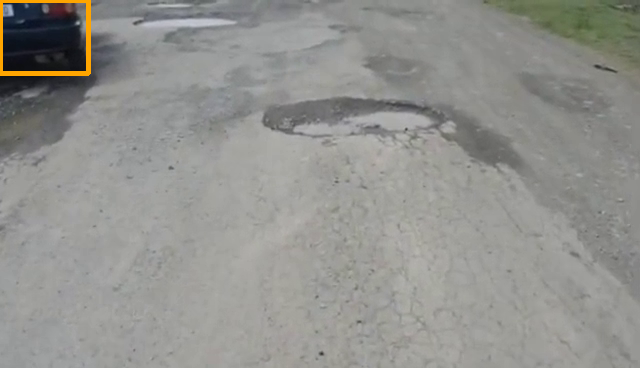

✅ Video finished.
✅ Done.


In [30]:
await stream_video_and_detect()
